In [1]:
# ============================================================
# İSTANBUL 39 İLÇE SU TÜKETİM TAHMİNİ - SARIMAX
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır
# ============================================================

In [2]:
# ── AŞAMA 1: KÜTÜPHANELERİ İÇE AKTAR ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

print('✅ Kütüphaneler yüklendi')

✅ Kütüphaneler yüklendi


In [3]:
# ── AŞAMA 2: DOSYA YOLLARI ─────────────────────────────────
ABONE_DOSYA    = r'C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\abone.xlsx'
SU_DOSYA       = r'C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\su_tuketim.xlsx'
SICAKLIK_DOSYA = r'C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\sicaklik.xlsx'

In [4]:
# ── AŞAMA 3: YARDIMCI FONKSİYON - TARİH PARSE ─────────────
AYLAR_TR = {
    'Ocak':1, 'Şubat':2, 'Mart':3, 'Nisan':4,
    'Mayıs':5, 'Haziran':6, 'Temmuz':7, 'Ağustos':8,
    'Eylül':9, 'Ekim':10, 'Kasım':11, 'Aralık':12
}

def tarih_parse(tarih_str):
    parcalar = str(tarih_str).strip().split()
    yil = int(parcalar[0])
    ay  = AYLAR_TR[parcalar[-1]]
    return pd.Timestamp(year=yil, month=ay, day=1)

In [5]:
# ── AŞAMA 4: ABONE VERİSİNİ YÜKLE ──────────────────────────
abone_raw = pd.read_excel(ABONE_DOSYA, header=1)

konut = abone_raw.iloc[:, 0:3].copy()
konut.columns = ['ilce', 'tarih', 'konut_abone']

isyeri = abone_raw.iloc[:, 8:11].copy()
isyeri.columns = ['ilce', 'tarih', 'isyeri_abone']

konut  = konut.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)
isyeri = isyeri.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)

konut['tarih']  = konut['tarih'].apply(tarih_parse)
isyeri['tarih'] = isyeri['tarih'].apply(tarih_parse)

abone_df = pd.merge(konut, isyeri, on=['ilce', 'tarih'], how='outer')
abone_df = abone_df[['ilce', 'tarih', 'konut_abone', 'isyeri_abone']]

print(f'✅ Abone verisi: {abone_df.shape[0]} satır, {abone_df["ilce"].nunique()} ilçe')

✅ Abone verisi: 2808 satır, 39 ilçe


In [6]:
# ── AŞAMA 5: SU TÜKETİM VERİSİNİ YÜKLE ────────────────────
su_raw = pd.read_excel(SU_DOSYA, header=1)

konut_su = su_raw.iloc[:, 0:3].copy()
konut_su.columns = ['ilce', 'tarih', 'konut_m3']

isyeri_su = su_raw.iloc[:, 4:7].copy()
isyeri_su.columns = ['ilce', 'tarih', 'isyeri_m3']

konut_su  = konut_su.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)
isyeri_su = isyeri_su.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)

konut_su['tarih']  = konut_su['tarih'].apply(tarih_parse)
isyeri_su['tarih'] = isyeri_su['tarih'].apply(tarih_parse)

konut_su['konut_m3']   = pd.to_numeric(konut_su['konut_m3'],   errors='coerce')
isyeri_su['isyeri_m3'] = pd.to_numeric(isyeri_su['isyeri_m3'], errors='coerce')

su_df = pd.merge(konut_su, isyeri_su, on=['ilce', 'tarih'], how='outer')
su_df = su_df[['ilce', 'tarih', 'konut_m3', 'isyeri_m3']]

print(f'✅ Su tüketim verisi: {su_df.shape[0]} satır, {su_df["ilce"].nunique()} ilçe')

✅ Su tüketim verisi: 2808 satır, 39 ilçe


In [7]:
# ── AŞAMA 6: SICAKLIK VERİSİNİ YÜKLE ───────────────────────
# header=1 → 2. satırı başlık olarak oku (ilk satır boş)
sicaklik_raw = pd.read_excel(SICAKLIK_DOSYA, header=1)

sicaklik_df = sicaklik_raw.rename(columns={
    "İLÇE": "ilce",
    "TARİH": "tarih",
    "ORTALAMA SICAKLIK": "sicaklik_c"
})

# "2020   Ocak" → datetime
tarih_split = sicaklik_df["tarih"].astype(str).str.strip().str.split(r"\s+", expand=True)
sicaklik_df["tarih"] = pd.to_datetime(
    tarih_split[0] + "-" + tarih_split[1].map(AYLAR_TR).astype(str),
    format="%Y-%m"
)

sicaklik_df["sicaklik_c"] = (
    sicaklik_df["sicaklik_c"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

sicaklik_df["ilce"] = sicaklik_df["ilce"].str.upper().str.strip()

print(f"✅ Sıcaklık verisi: {sicaklik_df.shape[0]} satır, {sicaklik_df['ilce'].nunique()} ilçe")

✅ Sıcaklık verisi: 2808 satır, 39 ilçe


In [8]:
# ── AŞAMA 7: İLÇE İSİMLERİNİ EŞLEŞTİR ─────────────────────
#eşleşmeyen ilçeler
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_abone    = set(abone_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())

print(f"Su verisi      : {len(ilce_su)} ilçe")
print(f"Abone verisi   : {len(ilce_abone)} ilçe")
print(f"Sıcaklık verisi: {len(ilce_sicaklik)} ilçe")

print("\n── Su ∩ Abone ──────────────────────────────")
print("🔴 Abonede olup suda OLMAYAN  :", ilce_abone - ilce_su)
print("🔵 Suda olup abonede OLMAYAN  :", ilce_su - ilce_abone)

print("\n── Su ∩ Sıcaklık ───────────────────────────")
print("🔴 Sıcaklıkta olup suda OLMAYAN  :", ilce_sicaklik - ilce_su)
print("🔵 Suda olup sıcaklıkta OLMAYAN  :", ilce_su - ilce_sicaklik)

print("\n── Üç sette birden olan ilçe sayısı ────────")
print("✅", len(ilce_su & ilce_abone & ilce_sicaklik), "ilçe tam eşleşiyor")

print("\n── Üç setten herhangi birinde eksik olanlar ─")
tum_ilceler = ilce_su | ilce_abone | ilce_sicaklik
eksik = {i: [] for i in tum_ilceler}
for i in tum_ilceler:
    if i not in ilce_su:       eksik[i].append("su yok")
    if i not in ilce_abone:    eksik[i].append("abone yok")
    if i not in ilce_sicaklik: eksik[i].append("sıcaklık yok")
eksik = {k: v for k, v in eksik.items() if v}
for ilce, sorun in sorted(eksik.items()):
    print(f"  {ilce:25s} → {', '.join(sorun)}")

Su verisi      : 39 ilçe
Abone verisi   : 39 ilçe
Sıcaklık verisi: 39 ilçe

── Su ∩ Abone ──────────────────────────────
🔴 Abonede olup suda OLMAYAN  : set()
🔵 Suda olup abonede OLMAYAN  : set()

── Su ∩ Sıcaklık ───────────────────────────
🔴 Sıcaklıkta olup suda OLMAYAN  : set()
🔵 Suda olup sıcaklıkta OLMAYAN  : set()

── Üç sette birden olan ilçe sayısı ────────
✅ 39 ilçe tam eşleşiyor

── Üç setten herhangi birinde eksik olanlar ─


In [9]:
# Aşama 7 sonrası doğrulama
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())
eksik = ilce_sicaklik - ilce_su
if eksik:
    print(f"⚠️  Hâlâ eşleşmeyen {len(eksik)} ilçe var: {eksik}")
else:
    print("✅ Tüm 39 ilçe eşleşiyor, devam edilebilir")

✅ Tüm 39 ilçe eşleşiyor, devam edilebilir


In [10]:
# ── AŞAMA 8: ÜÇ VERİYİ BİRLEŞTİR ──────────────────────────
df = (
    su_df
    .merge(abone_df,    on=['ilce', 'tarih'], how='inner')
    .merge(sicaklik_df, on=['ilce', 'tarih'], how='inner')
)

df = df[['ilce', 'tarih',
         'konut_m3', 'isyeri_m3',
         'konut_abone', 'isyeri_abone',
         'sicaklik_c']]

df['yil']  = df['tarih'].dt.year
df['ay']   = df['tarih'].dt.month
df['ilce'] = df['ilce'].str.upper().str.strip()

print(f'✅ Birleşik veri: {df.shape[0]} satır, {df["ilce"].nunique()} ilçe')
print(f'📅 Tarih aralığı: {df["tarih"].min().strftime("%Y-%m")} → {df["tarih"].max().strftime("%Y-%m")}')

✅ Birleşik veri: 2808 satır, 39 ilçe
📅 Tarih aralığı: 2020-01 → 2025-12


In [11]:
# ── AŞAMA 9: EĞİTİM / TEST BÖLÜNME ─────────────────────────
# Eğitim : 2020-01 → 2024-12
# Test   : 2025-01 → 2025-12  (12 ay)

EGITIM_BITIS   = '2024-12-01'
TEST_BASLANGIC = '2025-01-01'

df_train = df[df['tarih'] <= EGITIM_BITIS].copy()
df_test  = df[df['tarih'] >= TEST_BASLANGIC].copy()

ILCELER = sorted(df['ilce'].unique())
H = df_test['tarih'].nunique()

print(f'✅ Eğitim : {df_train["tarih"].min().strftime("%Y-%m")} → {df_train["tarih"].max().strftime("%Y-%m")}')
print(f'✅ Test   : {df_test["tarih"].min().strftime("%Y-%m")} → {df_test["tarih"].max().strftime("%Y-%m")}')
print(f'✅ Tahmin ufku: {H} ay  |  İlçe sayısı: {len(ILCELER)}')

✅ Eğitim : 2020-01 → 2024-12
✅ Test   : 2025-01 → 2025-12
✅ Tahmin ufku: 12 ay  |  İlçe sayısı: 39


In [12]:
# ── AŞAMA 10: METRİK FONKSİYONLARI ─────────────────────────
def mape(gercek, tahmin):
    mask = gercek != 0
    return np.mean(np.abs((gercek[mask] - tahmin[mask]) / gercek[mask])) * 100

def rmse(gercek, tahmin):
    return np.sqrt(mean_squared_error(gercek, tahmin))

def mae(gercek, tahmin):
    return mean_absolute_error(gercek, tahmin)

# Gerçek değer tablosu
gercek_df = df_test[['ilce', 'tarih', 'konut_m3', 'isyeri_m3']].copy()
gercek_df['toplam_gercek'] = gercek_df['konut_m3'] + gercek_df['isyeri_m3']
gercek_df = gercek_df.rename(columns={
    'konut_m3' : 'konut_gercek',
    'isyeri_m3': 'isyeri_gercek'
})

print('✅ Metrik fonksiyonları ve gerçek değer tablosu hazır')

✅ Metrik fonksiyonları ve gerçek değer tablosu hazır


In [13]:
# ── AŞAMA 11: SARIMAX TAHMİN FONKSİYONU ─────────────────────
# Sipariş   : SARIMA(1,1,1)(1,1,1)[12]
# Düzeltmeler:
#   1) StandardScaler ile exog ölçekleme
#   2) log1p dönüşümü (negatif tahmini önler)
#   3) Yakınsama kontrolü + fallback (exog'suz SARIMA)
#   4) enforce_stationarity=True (kararlılık için)

SARIMAX_ORDER    = (1, 1, 1)
SARIMAX_SEASONAL = (1, 1, 1, 12)
EXOG_COLS        = ['sicaklik_c', 'konut_abone', 'isyeri_abone']

def sarimax_tahmin(df_train, df_test, hedef_col, ilce,
                   order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEASONAL):
    """
    Tek ilçe, tek hedef sütun için SARIMAX modeli kurar ve tahmin döndürür.
    Düzeltmeler: StandardScaler + log1p + yakınsama kontrolü + fallback
    """
    egitim = df_train[df_train['ilce'] == ilce].set_index('tarih').sort_index()
    test   = df_test[df_test['ilce']   == ilce].set_index('tarih').sort_index()

    y_train_raw = egitim[hedef_col].ffill().bfill()

    # Düzeltme 1: StandardScaler ile exog ölçekleme
    scaler  = StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(egitim[EXOG_COLS].ffill().bfill()),
        columns=EXOG_COLS, index=egitim.index
    )
    X_test = pd.DataFrame(
        scaler.transform(test[EXOG_COLS].ffill().bfill()),
        columns=EXOG_COLS, index=test.index
    )

    # Düzeltme 2: log1p dönüşümü (negatif tahmini köründen keser)
    y_train = np.log1p(y_train_raw)

    def _fit_sarimax(y, X_tr, X_te, enf_stat=True):
        model = SARIMAX(
            y,
            exog=X_tr,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=enf_stat,
            enforce_invertibility=True,
        )
        return model.fit(disp=False, maxiter=300), X_te

    def _fit_sarima_fallback(y):
        """Yakınsamazsa exog'suz daha basit modele düş."""
        model = SARIMAX(
            y,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        return model.fit(disp=False, maxiter=300), None

    # Düzeltme 3: Yakınsama kontrolü + fallback
    sonuc, X_te_used = _fit_sarimax(y_train, X_train, X_test, enf_stat=True)

    if not sonuc.mle_retvals.get('converged', False):
        print(f'    ⚠ {ilce}/{hedef_col}: yakınsamadı → enforce_stationarity=False deneniyor')
        sonuc, X_te_used = _fit_sarimax(y_train, X_train, X_test, enf_stat=False)

    if not sonuc.mle_retvals.get('converged', False):
        print(f'    ⚠ {ilce}/{hedef_col}: hala yakınsamadı → exogsuz SARIMA fallback')
        sonuc, X_te_used = _fit_sarima_fallback(y_train)

    # Tahmin ve log geri-dönüşümü
    if X_te_used is not None:
        pred = sonuc.get_forecast(steps=len(X_test), exog=X_te_used)
    else:
        pred = sonuc.get_forecast(steps=len(test))

    tahmin_log = pred.predicted_mean
    conf_log   = pred.conf_int(alpha=0.05)

    # Düzeltme 2 devamı: expm1 ile orijinal ölçeğe dön
    tahmin = np.expm1(tahmin_log.values)
    lo_95  = np.expm1(conf_log.iloc[:, 0].values)
    hi_95  = np.expm1(conf_log.iloc[:, 1].values)

    # Güvenlik: negatif değerleri sıfırla
    tahmin = np.clip(tahmin, 0, None)
    lo_95  = np.clip(lo_95,  0, None)

    tahmin_df = pd.DataFrame({
        'tarih' : test.index,
        'tahmin': tahmin,
        'lo_95' : lo_95,
        'hi_95' : hi_95,
    })
    return tahmin_df, sonuc

print('✅ SARIMAX fonksiyonu tanımlandı (ölçekleme + log + fallback aktif)')

✅ SARIMAX fonksiyonu tanımlandı (ölçekleme + log + fallback aktif)


In [14]:
# ── AŞAMA 12: SARIMAX TAHMİNİ — TÜM İLÇELER ────────────────
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır

sarimax_sonuclar = []

for ilce in ILCELER:
    try:
        # Konut tahmini
        tahmin_k, _ = sarimax_tahmin(df_train, df_test, 'konut_m3', ilce)
        tahmin_k = tahmin_k.rename(columns={
            'tahmin': 'konut_tahmin',
            'lo_95' : 'konut_lo_95',
            'hi_95' : 'konut_hi_95',
        })

        # İşyeri tahmini
        tahmin_i, _ = sarimax_tahmin(df_train, df_test, 'isyeri_m3', ilce)
        tahmin_i = tahmin_i.rename(columns={
            'tahmin': 'isyeri_tahmin',
            'lo_95' : 'isyeri_lo_95',
            'hi_95' : 'isyeri_hi_95',
        })

        # Birleştir
        tek = tahmin_k.merge(tahmin_i, on='tarih')
        tek['ilce']          = ilce
        tek['toplam_tahmin'] = tek['konut_tahmin'] + tek['isyeri_tahmin']
        tek['toplam_lo_95']  = tek['konut_lo_95']  + tek['isyeri_lo_95']
        tek['toplam_hi_95']  = tek['konut_hi_95']  + tek['isyeri_hi_95']

        sarimax_sonuclar.append(tek)
        print(f'  ✅ {ilce}')
    except Exception as e:
        print(f'  ❌ {ilce}: {e}')

sarimax_df = pd.concat(sarimax_sonuclar).reset_index(drop=True)
print(f'\n✅ SARIMAX tahminleri tamamlandı: {sarimax_df.shape[0]} satır')

C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ADALAR


C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ARNAVUTKÖY


C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

  ✅ ÜSKÜDAR


C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ŞİLE


C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\mynet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ŞİŞLİ

✅ SARIMAX tahminleri tamamlandı: 468 satır


In [15]:
# ── AŞAMA 13: GERÇEK DEĞERLERLE BİRLEŞTİR ──────────────────
karsilastirma = sarimax_df.merge(gercek_df, on=['ilce', 'tarih'], how='inner')

print(f'✅ Karşılaştırma tablosu: {karsilastirma.shape[0]} satır')

✅ Karşılaştırma tablosu: 468 satır


In [16]:
# ── AŞAMA 14: PERFORMANS DEĞERLENDİRMESİ ────────────────────
metrikler = []

for ilce in ILCELER:

    k = karsilastirma[karsilastirma['ilce'] == ilce].copy()

    if k.empty:
        continue

    # ── NAN TEMİZLİĞİ ─────────────────────────────
    k = k.dropna(subset=[
        'konut_gercek', 'konut_tahmin',
        'isyeri_gercek', 'isyeri_tahmin',
        'toplam_gercek', 'toplam_tahmin'
    ])

    if k.empty:
        continue

    metrikler.append({
        'ilce'        : ilce,
        'MAPE_Konut'  : mape(k['konut_gercek'].values,  k['konut_tahmin'].values),
        'MAPE_Isyeri' : mape(k['isyeri_gercek'].values, k['isyeri_tahmin'].values),
        'MAPE_Toplam' : mape(k['toplam_gercek'].values, k['toplam_tahmin'].values),

        'MAE_Konut'   : mae(k['konut_gercek'].values,   k['konut_tahmin'].values),
        'MAE_Isyeri'  : mae(k['isyeri_gercek'].values,  k['isyeri_tahmin'].values),
        'MAE_Toplam'  : mae(k['toplam_gercek'].values,  k['toplam_tahmin'].values),

        'RMSE_Konut'  : rmse(k['konut_gercek'].values,  k['konut_tahmin'].values),
        'RMSE_Isyeri' : rmse(k['isyeri_gercek'].values, k['isyeri_tahmin'].values),
        'RMSE_Toplam' : rmse(k['toplam_gercek'].values, k['toplam_tahmin'].values),
    })

metrikler_df = pd.DataFrame(metrikler).sort_values('MAPE_Toplam')

print('\n📊 SARIMAX — İLÇE BAZLI PERFORMANS:')
print(metrikler_df.to_string(index=False))

print(f"\n🎯 Ort. MAPE  Konut  : {metrikler_df['MAPE_Konut'].mean():.2f}%")
print(f"🎯 Ort. MAPE  İşyeri : {metrikler_df['MAPE_Isyeri'].mean():.2f}%")
print(f"🎯 Ort. MAPE  Toplam : {metrikler_df['MAPE_Toplam'].mean():.2f}%")
print(f"🎯 Ort. MAE   Toplam : {metrikler_df['MAE_Toplam'].mean():,.0f} m³")
print(f"🎯 Ort. RMSE  Toplam : {metrikler_df['RMSE_Toplam'].mean():,.0f} m³")


📊 SARIMAX — İLÇE BAZLI PERFORMANS:
        ilce  MAPE_Konut  MAPE_Isyeri  MAPE_Toplam     MAE_Konut   MAE_Isyeri   MAE_Toplam    RMSE_Konut  RMSE_Isyeri  RMSE_Toplam
  BAYRAMPAŞA    8.400644    14.323176     6.136717  65788.070978 4.173788e+04 6.734316e+04  96551.192726 5.350051e+04 9.573306e+04
    BAĞCILAR    9.851869    12.966637     7.727832 213852.731510 8.566317e+04 2.099100e+05 315105.661916 1.276399e+05 3.177532e+05
     ESENLER    8.561782    21.316360     7.821289 103434.135210 4.928546e+04 1.116343e+05 165908.568998 6.015798e+04 1.881073e+05
   B.ÇEKMECE    8.824284    14.321654     8.418352 127412.264243 4.510523e+04 1.436263e+05 176352.248164 5.335128e+04 1.943020e+05
     MALTEPE    8.177832    13.527092     8.621418 142841.112115 5.879084e+04 1.896572e+05 186561.226663 8.274903e+04 2.469989e+05
    BAKIRKÖY    9.815350    14.982483     9.026600  86685.253721 6.553110e+04 1.164424e+05 116965.487893 9.079997e+04 1.822036e+05
     AVCILAR   10.198428    12.084667     9.217

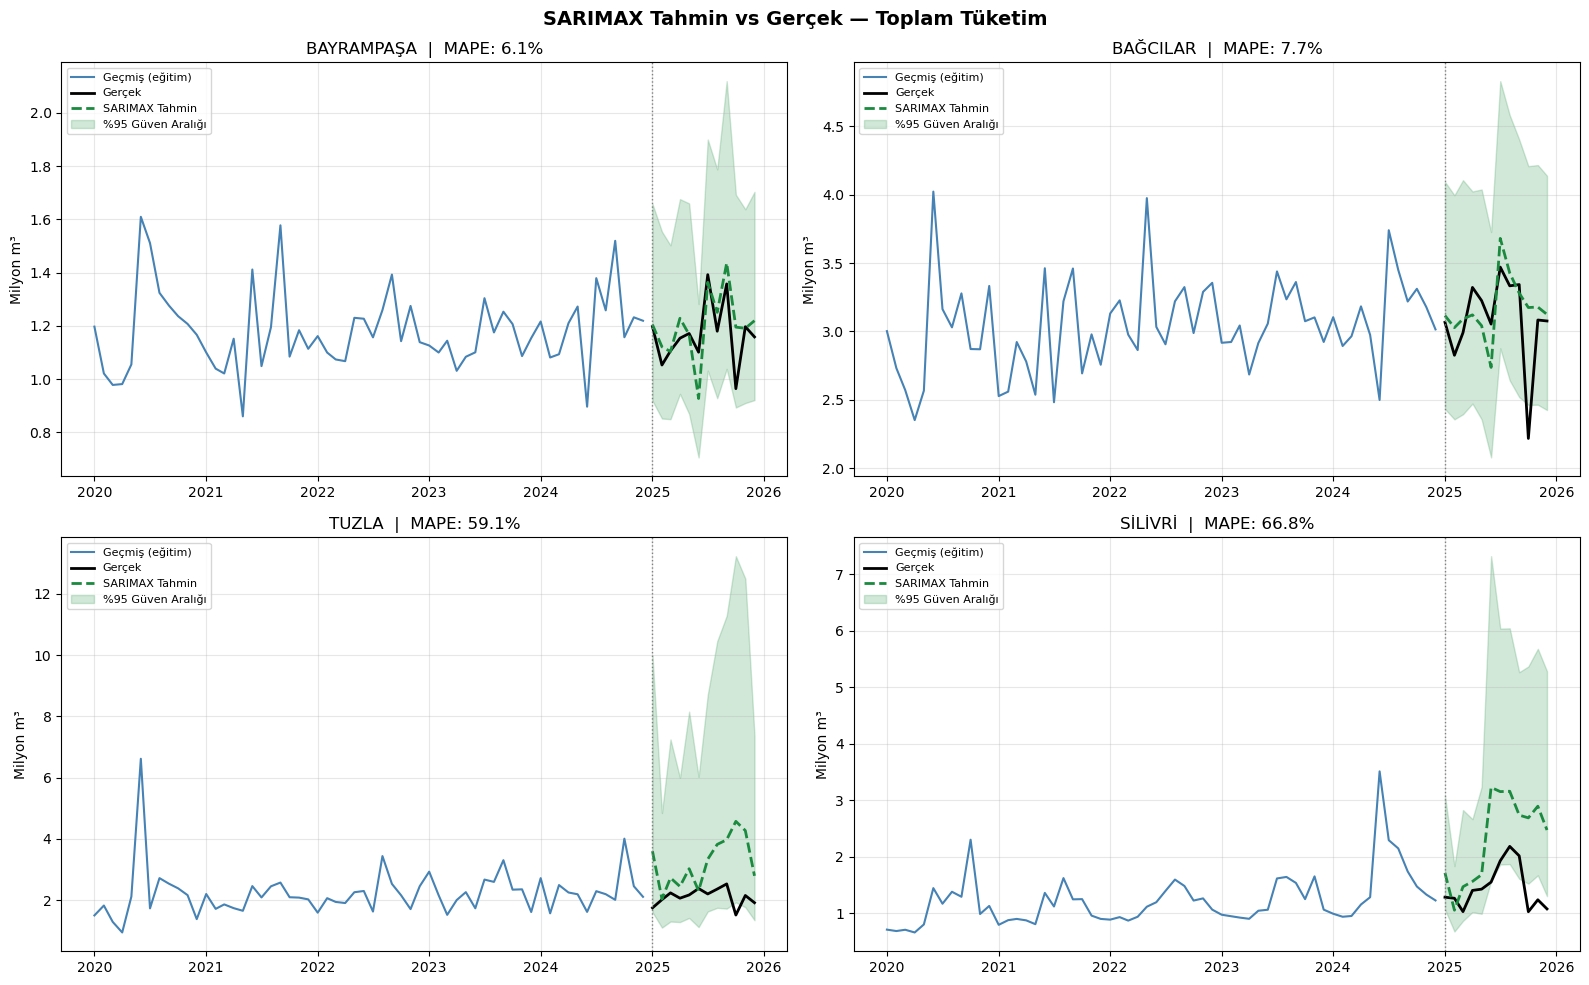

✅ SARIMAX grafikleri kaydedildi: sarimax_tahmin_grafikleri.png


In [17]:
# ── AŞAMA 15: TAHMİN GRAFİKLERİ ────────────────────────────
en_iyi  = metrikler_df.head(2)['ilce'].tolist()
en_kotu = metrikler_df.tail(2)['ilce'].tolist()
gosterilecek = en_iyi + en_kotu

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('SARIMAX Tahmin vs Gerçek — Toplam Tüketim', fontsize=14, fontweight='bold')

for ax, ilce in zip(axes.flatten(), gosterilecek):
    gecmis = df_train[df_train['ilce'] == ilce].copy()
    gecmis['toplam'] = gecmis['konut_m3'] + gecmis['isyeri_m3']
    k = karsilastirma[karsilastirma['ilce'] == ilce]
    mape_val = metrikler_df[metrikler_df['ilce'] == ilce]['MAPE_Toplam'].values[0]

    ax.plot(gecmis['tarih'], gecmis['toplam'] / 1e6,
            color='steelblue', linewidth=1.5, label='Geçmiş (eğitim)')
    ax.plot(k['tarih'], k['toplam_gercek'] / 1e6,
            color='black', linewidth=2, label='Gerçek')
    ax.plot(k['tarih'], k['toplam_tahmin'] / 1e6,
            color='#1a8a3e', linewidth=2, linestyle='--', label='SARIMAX Tahmin')
    ax.fill_between(k['tarih'],
                    k['toplam_lo_95'] / 1e6,
                    k['toplam_hi_95'] / 1e6,
                    alpha=0.2, color='#1a8a3e', label='%95 Güven Aralığı')
    ax.axvline(pd.Timestamp('2025-01-01'), color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{ilce}  |  MAPE: {mape_val:.1f}%')
    ax.set_ylabel('Milyon m³')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sarimax_tahmin_grafikleri.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SARIMAX grafikleri kaydedildi: sarimax_tahmin_grafikleri.png')

In [18]:
# ── AŞAMA 16: SONUÇLARI EXCEL'E KAYDET ─────────────────────

CIKTI_DOSYASI = r'C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_sarimax.xlsx'

# Eğitim dönemi bağlam verilerini hazırla (TimeGPT formatıyla uyumlu)
baglam_konut  = df_train[['ilce', 'tarih', 'konut_m3',  'sicaklik_c', 'konut_abone', 'isyeri_abone']].copy()
baglam_isyeri = df_train[['ilce', 'tarih', 'isyeri_m3', 'sicaklik_c', 'konut_abone', 'isyeri_abone']].copy()

# Kolon adını unique_id'ye çevir (karşılaştırma notebook'uyla uyumlu)
karsilastirma_xl  = karsilastirma.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
metrikler_xl      = metrikler_df.rename(columns={'ilce': 'unique_id'})
sarimax_df_xl     = sarimax_df.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
baglam_konut_xl   = baglam_konut.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
baglam_isyeri_xl  = baglam_isyeri.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
ham_veri_xl       = df.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})

with pd.ExcelWriter(CIKTI_DOSYASI, engine='openpyxl') as writer:
    karsilastirma_xl.to_excel( writer, sheet_name='Tahmin vs Gerçek', index=False)
    metrikler_xl.to_excel(     writer, sheet_name='Performans',        index=False)
    sarimax_df_xl.to_excel(    writer, sheet_name='Tahminler',         index=False)
    baglam_konut_xl.to_excel(  writer, sheet_name='Bağlam Konut',      index=False)
    baglam_isyeri_xl.to_excel( writer, sheet_name='Bağlam İşyeri',     index=False)
    ham_veri_xl.to_excel(      writer, sheet_name='Ham Veri',           index=False)

print(f'✅ Excel kaydedildi: {CIKTI_DOSYASI}')
print('\n🎉 SARIMAX işlemi tamamlandı!')


✅ Excel kaydedildi: C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_sarimax.xlsx

🎉 SARIMAX işlemi tamamlandı!
